# 1: Organizando

### 1.1: Importando as bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline



### 1.2: Carregando os dados

In [2]:
df = pd.read_csv("dados_usados/dados_para_modelo.csv")

In [3]:
df.head(10)

,status_do_emprestimo,valor_do_emprestimo,prazo_do_emprestimo_meses,taxa_de_juros,valor_da_parcela,tempo_de_emprego_anos,renda_anual,data_de_emissao_do_emprestimo,relacao_divida_renda,primeira_linha_de_credito,...,total_de_contas_de_credito,contas_de_hipoteca,registros_de_falencia,classificacao_de_risco,tipo_de_moradia,finalidade_do_emprestimo,tipo_de_aplicacao,taxa_de_juros_agrupada,taxa/falencia,juros/contas
0,0,10000.0,36,11.44,329.48,10.0,117000.0,2015,26.24,1990,...,25.0,0.0,0.0,0.874270,0.773378,0.810767,0.803913,0.25,11.44,64.0
1,0,8000.0,36,11.99,265.68,4.0,65000.0,2015,22.05,2004,...,27.0,3.0,0.0,0.874270,0.830439,0.792586,0.803913,0.50,11.99,34.0
2,0,15600.0,36,10.49,506.97,0.0,43057.0,2015,12.79,2007,...,26.0,0.0,0.0,0.874270,0.773378,0.832882,0.803913,0.25,10.49,52.0
3,0,7200.0,36,6.49,220.65,6.0,54000.0,2014,2.60,2006,...,13.0,0.0,0.0,0.937121,0.773378,0.832882,0.803913,0.25,6.49,24.0
4,1,24375.0,60,17.27,609.33,9.0,55000.0,2013,33.95,1999,...,43.0,1.0,0.0,0.788191,0.830439,0.832882,0.803913,0.50,17.27,26.0
5,0,20000.0,36,13.33,677.07,10.0,86788.0,2015,16.31,2005,...,23.0,4.0,0.0,0.788191,0.830439,0.792586,0.803913,0.50,13.33,16.0
6,0,18000.0,36,5.32,542.07,2.0,125000.0,2015,1.36,2005,...,25.0,3.0,0.0,0.937121,0.830439,0.829921,0.803913,0.25,5.32,32.0
7,0,13000.0,36,11.14,426.47,10.0,46000.0,2012,26.87,1994,...,15.0,0.0,0.0,0.874270,0.773378,0.832882,0.803913,0.25,11.14,44.0
8,0,18900.0,60,10.99,410.84,10.0,103000.0,2014,12.52,1994,...,40.0,3.0,0.0,0.874270,0.773378,0.792586,0.803913,0.25,10.99,52.0
9,0,26300.0,36,16.29,928.40,3.0,115000.0,2012,23.69,1997,...,37.0,1.0,0.0,0.788191,0.830439,0.792586,0.803913,0.50,16.29,26.0


In [4]:
df.tail(10)

,status_do_emprestimo,valor_do_emprestimo,prazo_do_emprestimo_meses,taxa_de_juros,valor_da_parcela,tempo_de_emprego_anos,renda_anual,data_de_emissao_do_emprestimo,relacao_divida_renda,primeira_linha_de_credito,...,total_de_contas_de_credito,contas_de_hipoteca,registros_de_falencia,classificacao_de_risco,tipo_de_moradia,finalidade_do_emprestimo,tipo_de_aplicacao,taxa_de_juros_agrupada,taxa/falencia,juros/contas
383411,0,10000.0,36,9.76,321.55,10.0,40000.0,2015,23.40,1988,...,18.0,1.0,0.0,0.874270,0.773378,0.792586,0.803913,0.25,9.76,36.0
383412,0,3200.0,36,5.42,96.52,10.0,33000.0,2011,21.45,1996,...,50.0,1.0,0.0,0.937121,0.773378,0.792586,0.803913,0.25,5.42,72.0
383413,0,12000.0,36,12.29,400.24,1.0,52100.0,2015,17.28,2004,...,18.0,0.0,0.0,0.788191,0.773378,0.792586,0.803913,0.50,12.29,12.0
383414,0,22000.0,36,18.92,805.55,10.0,138000.0,2014,24.43,1998,...,39.0,4.0,0.0,0.711322,0.830439,0.792586,0.803913,0.75,18.92,24.0
383415,0,6000.0,36,13.11,202.49,5.0,64000.0,2013,10.81,1991,...,9.0,0.0,0.0,0.874270,0.773378,0.792586,0.803913,0.50,13.11,14.0
383416,0,10000.0,60,10.99,217.38,2.0,40000.0,2015,15.63,2004,...,23.0,0.0,0.0,0.874270,0.773378,0.792586,0.803913,0.25,10.99,24.0
383417,0,21000.0,36,12.29,700.42,5.0,110000.0,2015,21.45,2006,...,8.0,1.0,0.0,0.788191,0.830439,0.792586,0.803913,0.50,12.29,12.0
383418,0,5000.0,36,9.99,161.32,10.0,56500.0,2013,17.56,1997,...,23.0,0.0,0.0,0.874270,0.773378,0.792586,0.803913,0.25,9.99,60.0
383419,0,21000.0,60,15.31,503.02,10.0,64000.0,2012,15.88,1990,...,20.0,5.0,0.0,0.788191,0.830439,0.792586,0.803913,0.50,15.31,18.0
383420,0,2000.0,36,13.61,67.98,10.0,42996.0,2010,8.32,1998,...,19.0,1.0,0.0,0.788191,0.773378,0.792586,0.803913,0.50,13.61,6.0


### 1.3: Separando dados de treino e teste

In [5]:
# x = todos os dados do df, menos a coluna "status_do_emprestimo" que o modelo tentara prever
# y = a coluna "status_do_emprestimo" que o modelo tentara prever

x = df.drop("status_do_emprestimo", axis=1)
y = df["status_do_emprestimo"]

In [6]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383421 entries, 0 to 383420
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   valor_do_emprestimo             383421 non-null  float64
 1   prazo_do_emprestimo_meses       383421 non-null  int64  
 2   taxa_de_juros                   383421 non-null  float64
 3   valor_da_parcela                383421 non-null  float64
 4   tempo_de_emprego_anos           383421 non-null  float64
 5   renda_anual                     383421 non-null  float64
 6   data_de_emissao_do_emprestimo   383421 non-null  int64  
 7   relacao_divida_renda            383421 non-null  float64
 8   primeira_linha_de_credito       383421 non-null  int64  
 9   contas_de_credito_abertas       383421 non-null  float64
 10  registros_publicos_negativos    383421 non-null  float64
 11  saldo_de_credito_rotativo       383421 non-null  float64
 12  utilizacao_do_cr

In [7]:
y.value_counts()

status_do_emprestimo
0    308372
1     75049
Name: count, dtype: int64

In [8]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, stratify= y, random_state=42)

In [9]:
len(x_train), len(y_train)

(306736, 306736)

In [10]:
len(x_test), len(y_test)

(76685, 76685)

### 1.4: Organizando os modelos para passar num laço e avaliar quão eficiente é cada um deles sem organizar os hiperparametros


In [11]:
# Os modelos de Logistic e de KNN precisam de um escalonamento de dados, por isso o StandartScaler 
pipeline_logistic = Pipeline(
   [ ("scaler", StandardScaler()),
    ("model", LogisticRegression())]
)

pipeline_knn = Pipeline(
    [("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())]
)

In [12]:
modelos = {
    "KNN" : pipeline_knn,
    "Logistic Regressionr" : pipeline_logistic,
    "Ramdom Forest" : RandomForestClassifier(random_state=42),
    "XGBoosting" : XGBClassifier(random_state=42),
    "Lightgbm" : LGBMClassifier(random_state=42)
}

# 2: Treinando os modelos

### 2.1: Treinando os modelos sem organizar os hiperparametros

In [13]:
avaliacao = {}

for name, modelo in modelos.items():
    cross_score = cross_val_score(
        modelo, x_train, y_train,
        cv=5,
        scoring= "roc_auc"
    )
    avaliacao[name] = np.mean(cross_score)
    print(f"{name} : {avaliacao[name]}")


KNN : 0.6263537498328859
Logistic Regressionr : 0.707326491157081
Ramdom Forest : 0.7096237377676298
XGBoosting : 0.7244329961593386
[LightGBM] [Info] Number of positive: 48031, number of negative: 197357
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009934 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2341
[LightGBM] [Info] Number of data points in the train set: 245388, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.195735 -> initscore=-1.413168
[LightGBM] [Info] Start training from score -1.413168
[LightGBM] [Info] Number of positive: 48032, number of negative: 197357
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007644 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM

### 2.2: Organizando os hiperparametros para cada modelo

In [14]:
knn_params = {
  "model__n_neighbors" : [1, 3, 5, 7, 9, 20, 30, 50],
  "model__weights" : ["uniform", "distance"]
}

random_forest_params = {
    "random_state" : [42],
    "n_estimators" : np.arange(300, 1500, 90),
    "max_depth" : [1, 5, 9, 20, 50],
    "min_samples_leaf" : np.arange(1, 10, 3),
    "min_samples_split" : np.arange(1, 15, 3)
}

logistic_params = {
    "model__C" : np.logspace(-3, 3, 10),
    "model__solver" : ["lbfgs", "liblinear"]
}

gradient_boosting_params = {
    "random_state" : [42],
    "n_estimators" : np.arange(100, 1080, 80),
    "max_depth" : [1, 3, 9, 15],
    "subsample" : [0.2, 0.5, 0.7, 1],
    "min_child_weight" : np.arange(1, 10, 3),
    "scale_pos_weight" : [10, 20, 5, 15, ]
}

light_params = {
    "random_state" : [42],
    "num_leaves" : [63, 127],
    "n_estimators" : [100, 300, 500, 1000],
    "min_child_sample" : [100, 300, 500, 1000],
    "max_depth" : [1, 5, 7],
    "subsample" : [0.2, 0.5, 1],
    "is_unbalance" : [True],
    "colsample_bytree" : [0.2, 1],
    "learning_rate" : [0.2, 1],
    "force_row_wise" : [True]
}



In [15]:
# Esse processo de amostragem é necessário para reduzir o tempo gasto no processo, usarei so no ramdomforest que o meu pc não estava aguentando rodar completo
x_sample,_, y_sample,_ = train_test_split(x_train, y_train, train_size=100000, stratify=y_train, random_state=42)

### 2.3: Fazendo uma função que mostre o resultado de cada hiperparametro, passando por um crossvalidation para concluir e testando  os que tem melhor average_score

In [16]:
def test_randomized_search(model, params, x_sample, y_sample):
    randomized = HalvingRandomSearchCV(
    model,
    params,
    cv= 5,
    n_candidates = 50,
    factor=3,
    scoring="roc_auc",
    n_jobs = -1,
    min_resources= 6000,
    random_state=42,
    verbose=2
)

    randomized.fit(x_sample, y_sample)
    print(f"O melhor score foi: {randomized.best_score_}")
    print(f"Os melhores parametros foram: {randomized.best_params_}")

    return randomized
    


In [17]:
knn_modelo = test_randomized_search(pipeline_knn, knn_params, x_train, y_train)

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 4
min_resources_: 6000
max_resources_: 306736
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 16
n_resources: 6000
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 16 is smaller than n_iter=50. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END .......model__n_neighbors=1, model__weights=uniform; total time=   0.1s
[CV] END ......model__n_neighbors=1, model__weights=distance; total time=   0.1s
[CV] END .......model__n_neighbors=1, model__weights=uniform; total time=   0.1s
[CV] END ......model__n_neighbors=1, model__weights=distance; total time=   0.1s
[CV] END .......model__n_neighbors=1, model__weights=uniform; total time=   0.1s
[CV] END ......model__n_neighbors=1, model__weights=distance; total time=   0.1s
[CV] END ......model__n_neighbors=1, model__weights=distance; total time=   0.1s
[CV] END .......model__n_neighbors=1, model__weights=uniform; total time=   0.1s
[CV] END .......model__n_neighbors=3, model__weights=uniform; total time=   0.1s
[CV] END .......model__n_neighbors=3, model__weights=uniform; total time=   0.1s
[CV] END .......model__n_neighbors=3, model__weights=uniform; total time=   0.1s
[CV] END .......model__n_neighbors=3, model__weights=uniform; total time=   0.1s
[CV] END .......model__n_nei

In [18]:
logistic_modelo = test_randomized_search(pipeline_logistic, logistic_params, x_train, y_train)

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 4
min_resources_: 6000
max_resources_: 306736
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 20
n_resources: 6000
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END ................model__C=0.001, model__solver=lbfgs; total time=   0.0s


/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 20 is smaller than n_iter=50. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END ................model__C=0.001, model__solver=lbfgs; total time=   0.0s
[CV] END ................model__C=0.001, model__solver=lbfgs; total time=   0.0s
[CV] END ................model__C=0.001, model__solver=lbfgs; total time=   0.0s
[CV] END ................model__C=0.001, model__solver=lbfgs; total time=   0.1s
[CV] END ............model__C=0.001, model__solver=liblinear; total time=   0.1s
[CV] END ............model__C=0.001, model__solver=liblinear; total time=   0.1s
[CV] END ............model__C=0.001, model__solver=liblinear; total time=   0.1s
[CV] END ............model__C=0.001, model__solver=liblinear; total time=   0.1s
[CV] END .model__C=0.004641588833612777, model__solver=lbfgs; total time=   0.1s
[CV] END ............model__C=0.001, model__solver=liblinear; total time=   0.1s
[CV] END .model__C=0.004641588833612777, model__solver=lbfgs; total time=   0.0s
[CV] END .model__C=0.004641588833612777, model__solver=lbfgs; total time=   0.1s
[CV] END .model__C=0.0046415

In [19]:
xgb_modelo = test_randomized_search(XGBClassifier(), gradient_boosting_params, x_train, y_train)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 6000
max_resources_: 306736
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 50
n_resources: 6000
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END max_depth=15, min_child_weight=7, n_estimators=100, random_state=42, scale_pos_weight=10, subsample=1; total time=   2.6s
[CV] END max_depth=15, min_child_weight=7, n_estimators=100, random_state=42, scale_pos_weight=10, subsample=1; total time=   2.6s
[CV] END max_depth=15, min_child_weight=7, n_estimators=100, random_state=42, scale_pos_weight=10, subsample=1; total time=   2.6s
[CV] END max_depth=15, min_child_weight=7, n_estimators=100, random_state=42, scale_pos_weight=10, subsample=1; total time=   2.8s
[CV] END max_depth=15, min_child_weight=7, n_estimators=100, random_state=42, scale_pos_weight=10, subsample=1; total time=   2.8s
[CV] END max_depth=3, min_child_weight=4, n_estimators=420, random_state=42, sc

In [20]:
#lightgbm testando os hiperparametros estava travando meu pc, então não pude testar, 
# mas mesmo testando hiperparametros dos outros modelos, 
# ele ainda é um pouco superior mesmo sem ajustar os hiperparametros
#light_modelo = test_randomized_search(LGBMClassifier(), light_params, x_sample, y_sample)

In [21]:
#coloquei so um sample de 100.000 linhas para testar os hiperparametros do random forest, para rodar mais rapido e pesar menos no pc
random_forest_modelo = test_randomized_search(RandomForestClassifier(), random_forest_params, x_sample, y_sample)

n_iterations: 3
n_required_iterations: 4
n_possible_iterations: 3
min_resources_: 6000
max_resources_: 100000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 50
n_resources: 6000
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END max_depth=5, min_samples_leaf=7, min_samples_split=1, n_estimators=480, random_state=42; total time=   0.0s[CV] END max_depth=5, min_samples_leaf=7, min_samples_split=1, n_estimators=480, random_state=42; total time=   0.0s

[CV] END max_depth=5, min_samples_leaf=7, min_samples_split=1, n_estimators=480, random_state=42; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=7, min_samples_split=1, n_estimators=480, random_state=42; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=7, min_samples_split=1, n_estimators=480, random_state=42; total time=   0.0s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=13, n_estimators=570, random_state=42; total time=   6.5s
[CV] END max_depth=20, min_sam

/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
65 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
65 fits failed with the following error:
Traceback (most recent call last):
  File "/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
  File "/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/base.py", line 492, in _validate_params
    valida

[CV] END max_depth=20, min_samples_leaf=7, min_samples_split=13, n_estimators=480, random_state=42; total time=  14.2s
[CV] END max_depth=20, min_samples_leaf=7, min_samples_split=13, n_estimators=480, random_state=42; total time=  15.1s
[CV] END max_depth=20, min_samples_leaf=7, min_samples_split=13, n_estimators=480, random_state=42; total time=  15.6s
[CV] END max_depth=20, min_samples_leaf=7, min_samples_split=13, n_estimators=300, random_state=42; total time=   9.5s
[CV] END max_depth=20, min_samples_leaf=7, min_samples_split=13, n_estimators=480, random_state=42; total time=  14.7s
[CV] END max_depth=20, min_samples_leaf=7, min_samples_split=13, n_estimators=480, random_state=42; total time=  15.3s
[CV] END max_depth=20, min_samples_leaf=7, min_samples_split=13, n_estimators=300, random_state=42; total time=   9.5s
[CV] END max_depth=20, min_samples_leaf=7, min_samples_split=13, n_estimators=300, random_state=42; total time=   9.2s
[CV] END max_depth=20, min_samples_leaf=7, min_s

/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan 0.69921257 0.70966278 0.71078758 0.69491005 0.70901437
 0.69482046        nan 0.69368597 0.7008093  0.71034961 0.69776406
 0.69482687 0.7097961         nan 0.70660487 0.70904783 0.70993129
 0.69838174 0.69563923 0.70989721        nan        nan 0.7069332
        nan 0.69491005        nan        nan 0.71079952 0.69482046
        nan 0.71084447        nan 0.70718578 0.69491539 0.70307681
 0.71042989 0.71087929        nan 0.71081565 0.70674862 0.70251705
 0.69795587 0.69603257        nan 0.69383775 0.69475891 0.70870741
 0.70690885        nan 0.71510201 0.71505163 0.71484763 0.71588558
 0.71575693 0.71661088 0.71604106 0.71594686 0.7112344  0.71615245
 0.7160686  0.71607853 0.71147128 0.71143346 0.71140929 0.71154208
 0.71137521]
  warnings.warn(
/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/m

[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=13, n_estimators=1110, random_state=42; total time= 1.6min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=13, n_estimators=1110, random_state=42; total time= 1.6min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=13, n_estimators=1110, random_state=42; total time= 1.6min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=10, n_estimators=1470, random_state=42; total time= 2.0min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=10, n_estimators=1470, random_state=42; total time= 2.1min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=10, n_estimators=1470, random_state=42; total time= 2.1min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=10, n_estimators=1470, random_state=42; total time= 2.1min
[CV] END max_depth=9, min_samples_leaf=1, min_samples_split=10, n_estimators=1470, random_state=42; total time= 2.1min
[CV] END max_depth=9, min_samples_leaf=4, min_sa

/home/Erick/miniconda3/envs/data/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan 0.69921257 0.70966278 0.71078758 0.69491005 0.70901437
 0.69482046        nan 0.69368597 0.7008093  0.71034961 0.69776406
 0.69482687 0.7097961         nan 0.70660487 0.70904783 0.70993129
 0.69838174 0.69563923 0.70989721        nan        nan 0.7069332
        nan 0.69491005        nan        nan 0.71079952 0.69482046
        nan 0.71084447        nan 0.70718578 0.69491539 0.70307681
 0.71042989 0.71087929        nan 0.71081565 0.70674862 0.70251705
 0.69795587 0.69603257        nan 0.69383775 0.69475891 0.70870741
 0.70690885        nan 0.71510201 0.71505163 0.71484763 0.71588558
 0.71575693 0.71661088 0.71604106 0.71594686 0.7112344  0.71615245
 0.7160686  0.71607853 0.71147128 0.71143346 0.71140929 0.71154208
 0.71137521 0.71547827 0.71552    0.71570399 0.71575421 0.71549498
 0.71571839]
  warnings.warn(
/hom

O melhor score foi: 0.7157542087302959
Os melhores parametros foram: {'random_state': 42, 'n_estimators': np.int64(750), 'min_samples_split': np.int64(13), 'min_samples_leaf': np.int64(4), 'max_depth': 9}


# 3: Testando o melhor modelo

### 3.1: Pegando o melhor modelo para ser testado

In [22]:
best_modelo = xgb_modelo.best_estimator_

In [25]:
best_modelo

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [26]:
best_modelo.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### 3.2: Testando os resultados do modelo

In [27]:
# Calculando as probabilidades de previsão para a classe positiva (1)
y_proba = best_modelo.predict_proba(x_test)[0:, 1]

In [28]:
y_proba

array([0.8671208 , 0.8374629 , 0.7134302 , ..., 0.14958449, 0.7942315 ,
       0.38491932], shape=(76685,), dtype=float32)

### 3.3 Olhando outros scorings para avaliar o modelo

In [29]:
roc_auc = roc_auc_score(y_test, y_proba)
roc_auc

0.720239383715815

In [30]:
numero_aleatorio = np.arange(0.6, 0.95, 0.01)
numero_y_pred = 0
for i in numero_aleatorio:
    y_pred = (y_proba >= i).astype(int)
    f1 = f1_score(y_test, y_pred)
    if numero_y_pred < f1:
        numero_y_pred = f1
        melhor_numero = i

melhor_numero

np.float64(0.7300000000000001)

In [31]:
#fui testando perto do valor do threshold de 0.70, o melhor foi esse
y_pred = (y_proba >= melhor_numero).astype(int)

In [32]:
f1 = f1_score(y_test, y_pred)
f1

0.43671573498486355

In [33]:
precision = precision_score(y_test, y_pred)
precision

0.33432402788097515

In [34]:
recall = recall_score(y_test, y_pred)
recall

0.6295136575616256

In [35]:
average = average_precision_score(y_test, y_proba)
average

0.38051914530471975

### 3.4: Olhando quantos acertos e erros o modelo tem com o y_pred  usando y_proba > melhor número

In [36]:
matriz_confusao = confusion_matrix(y_test, y_pred)

In [37]:
matriz_confusao

array([[42861, 18814],
       [ 5561,  9449]])

In [38]:
probabilidade_acertos_bons_pagadores = (1 / ((matriz_confusao[1][0] + matriz_confusao[0][0]) / matriz_confusao[0][0])) * 100
probabilidade_acertos_inadimplestes = (1 / ((matriz_confusao[1][1] + matriz_confusao[0][1] ) / matriz_confusao[1][1])) * 100

In [39]:
print(f"a probabilidade de acertar bons pagadores com esse threshold é {probabilidade_acertos_bons_pagadores}")
print(f"a probabilidade de acertar inadimplentes com esse threshold é {probabilidade_acertos_inadimplestes}")


a probabilidade de acertar bons pagadores com esse threshold é 88.51555078270208
a probabilidade de acertar inadimplentes com esse threshold é 33.43240278809751


# 4: Olhando os dados do porque o modelo ter essa performance

### 4.1: Organizando o SHAP para olhar os dados e entender o porque o modelo tem essa performance

In [40]:
shap.initjs()

In [41]:
#Peganndo o modelo para explicar as previsões
explaned = shap.TreeExplainer(best_modelo)
shap_values = explaned(x_test)

In [42]:
shap_values.shape


(76685, 23)

### 4.2: OLhando os gráficos do SHAP para entender o porque o modelo tem essa performance

Esse sumario mostra com os vermelhos o que mais pesa na decisão do modelo, e os azuis o que menos pesa, e o mais importante é olhar a direção da seta, se ela aponta para a direita, significa que aquele valor aumenta a probabilidade de ser 1, e se aponta para a esquerda, significa que aquele valor aumenta a probabilidade de ser 0.

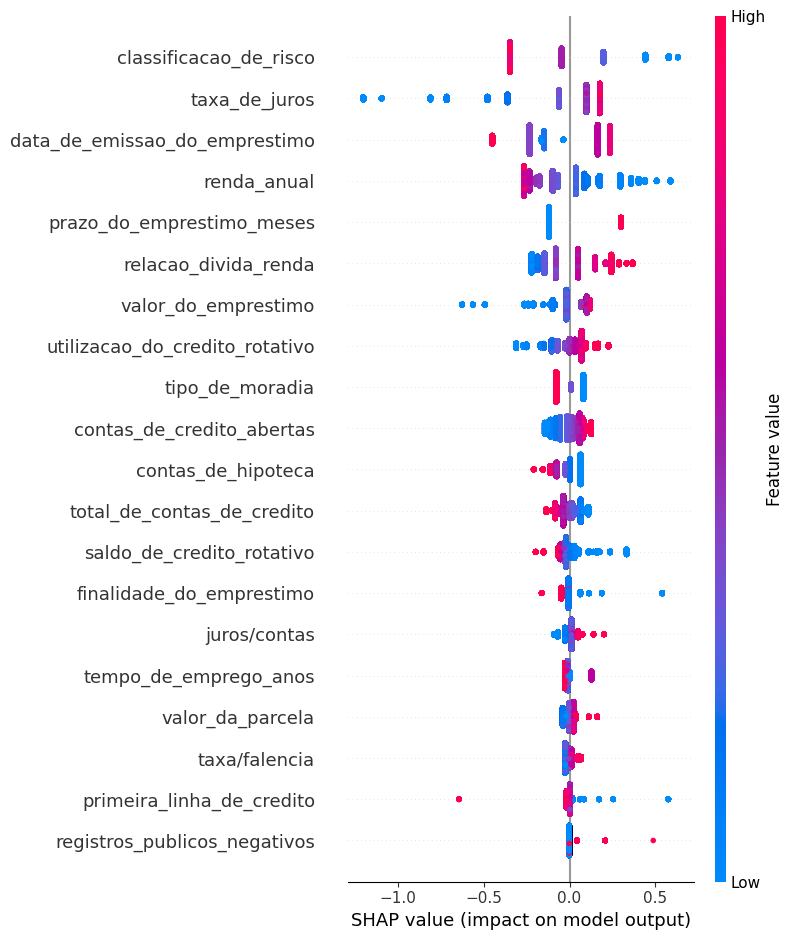

In [43]:
sumario1 = shap.summary_plot(shap_values, x_test)

Esse gráfico de barras mostra o peso de cada feature para decisão do modelo

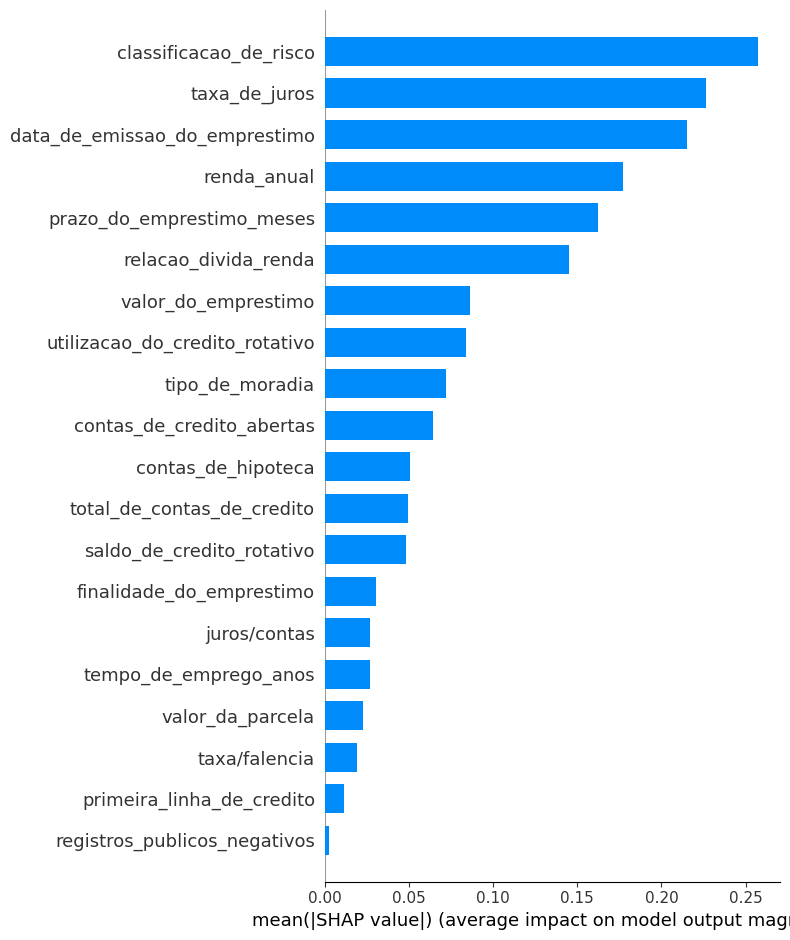

In [44]:
sumario2 = shap.summary_plot(shap_values, x_train, plot_type="bar")

Esse gráfico do shap de força mostra o peso de cada feature para cada valor, e a direção da seta mostra se aquele valor aumenta a probabilidade de ser 1 ou 0, e a cor mostra se aquele valor é alto ou baixo.

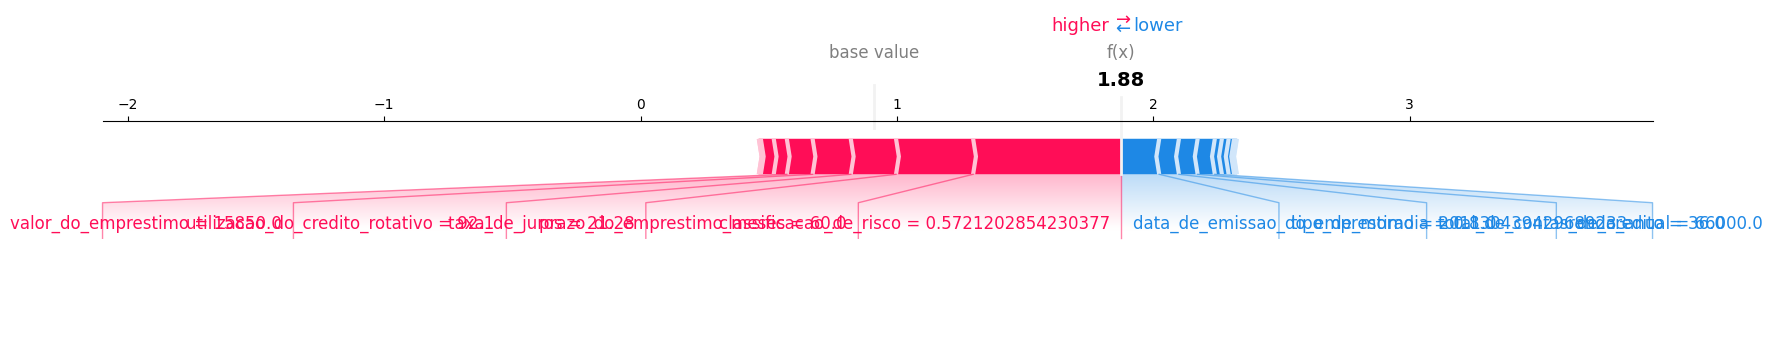

In [45]:
grafico_forca = shap.plots.force(shap_values[0], matplotlib=True)

Mesmo gráfico de força com outro valor

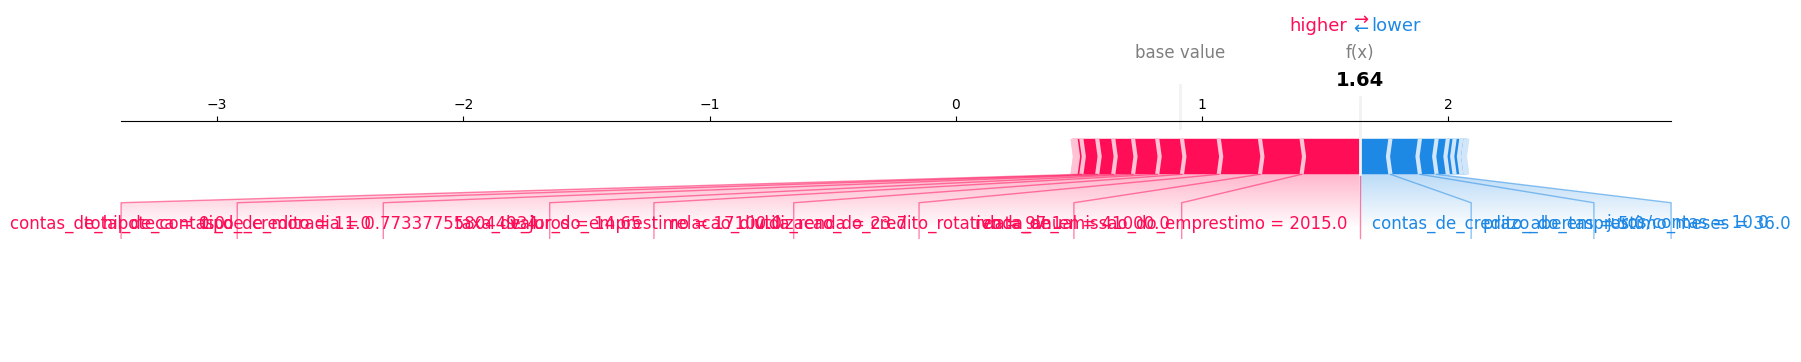

In [46]:
grafico_forca = shap.plots.force(shap_values[1], matplotlib=True)

Esse gráfico de cascata mostra o peso de cada feature para cada valor, e a direção da seta mostra se aquele valor aumenta a probabilidade de ser 1 ou 0, e a cor mostra se aquele valor é alto ou baixo, e a diferença é que ele mostra o peso acumulado de cada feature, ou seja, ele mostra o peso de cada feature para cada valor, e o peso acumulado de cada feature para cada valor.

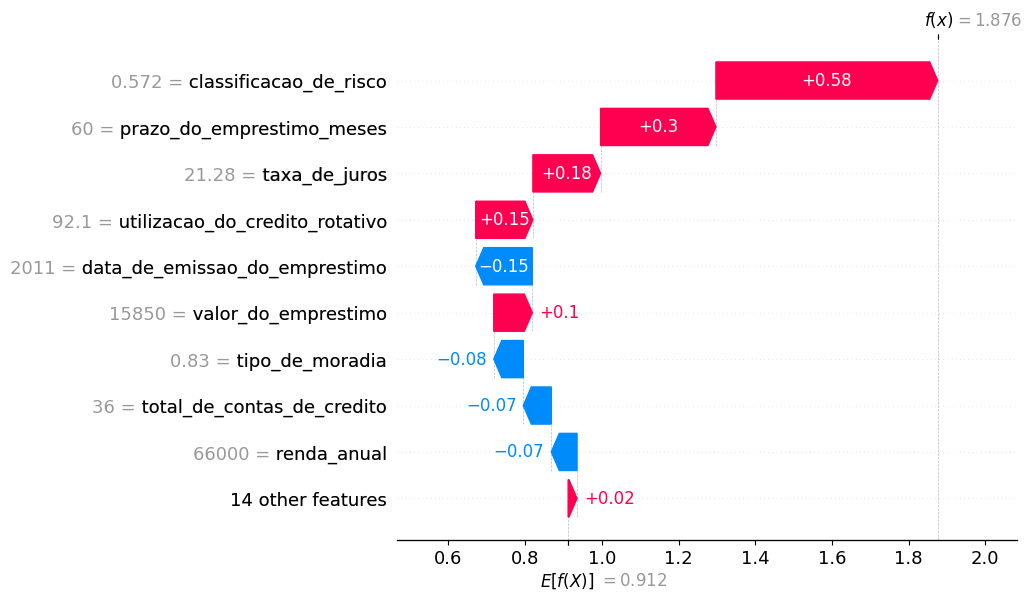

In [48]:
grafico_waterfall = shap.plots.waterfall(shap_values[0, :],)